# A camera that is wrong the same way every time

### Locating a warehouse robot with a camera on the wall, starting from nothing

This notebook assumes no prior knowledge of this project. It starts with a robot in a
room and ends with a result about what a camera can and cannot tell that robot about
where it is.

**The one-sentence version.** A wall camera can tell a warehouse robot where it is, but
it is wrong by about half a robot width *in the same direction every time*. That error
cannot be averaged away and cannot be hidden inside the robot's stated uncertainty, so
it has to be estimated — and there is one direction in which no single camera can ever
estimate it.

---

### The rules this notebook plays by

Every assumption below is one a real warehouse could actually satisfy. Anything that
breaks that rule is labelled where it happens.

| the robot may use, while driving | the robot may **not** use, while driving |
|---|---|
| the camera image | ground truth of any kind |
| where the camera is bolted, and its lens spec | the robot's CAD model or 3-D mesh |
| wheel odometry | any correction table measured beforehand |
| the warehouse floorplan (where the shelves are) | anything fitted on the drive it is filtering |

Ground truth appears **only** to score. The robot's exact 3-D shape appears exactly
once, in Part 1, to explain to *you* why the error exists. It is never given to the
estimator.

All data is recorded from Gazebo. Nothing here is synthetic.

In [1]:
import math

import numpy as np

import notebook_data as nd
import story_model as sm
import story_views as sv

sv.style()
nd.use_world(nd.AWS_SINGLE)
models = nd.camera_models()
camera = models["camera_A"]

# The drives. Four straight runs that differ in range, bearing and occlusion; a pair that
# drive the SAME line in opposite directions; and three that turn.
CORE = ["aws_aisle_east_north", "aws_apron_west_to_east",
        "aws_aisle_west_north", "aws_mid_cross_east"]
REVERSAL = ["aws_apron_diagonal_ne", "aws_apron_diagonal_sw"]
TURNING = ["aws_apron_corner_left", "aws_apron_arc_left", "aws_apron_reverse_spin"]

drives = [sm.drive(tag, models) for tag in CORE + REVERSAL + TURNING]
by_tag = {d["tag"]: d for d in drives}
lead = by_tag["aws_aisle_east_north"]

print(f"{len(drives)} recorded Gazebo drives, "
      f"{sum(len(d['rows']) for d in drives)} detections with ground truth")
print(f"camera: mounted at {tuple(round(float(v), 2) for v in camera.cam_pos)} m, "
      f"{camera.img_width}x{camera.img_height}, "
      f"{math.degrees(camera.fov_h_rad):.0f}° wide")

/home/joostleliveld/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


9 recorded Gazebo drives, 1484 detections with ground truth
camera: mounted at (0.0, -5.5, 4.8) m, 1280x720, 90° wide


## Part 0 — Why a robot needs a camera at all

### 0.1 A robot that counts its wheels loses track of itself

A warehouse robot tracks where it is by counting wheel rotations. Every slip, every
uneven floor tile, every turn adds a small error — and nothing ever takes it back off
again. The error only grows.

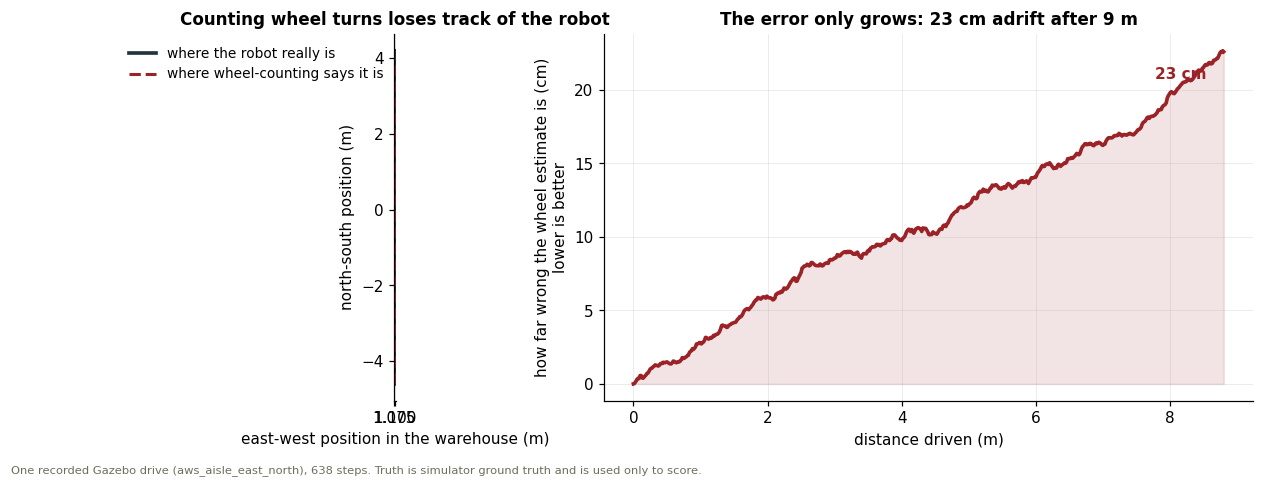

In [2]:
sv.odometry_drifts(lead);

### 0.2 Turning a picture into a position

Warehouses already have cameras on the walls, and a camera does not drift. But it does
not output a position either — it outputs an image. Three steps get you a number:

1. a detector draws a box around the robot;
2. take the **bottom-centre pixel** of that box, because that is roughly where the robot
   meets the floor;
3. shoot a ray through that pixel and see where it hits the floor.

There is nothing fitted in step 3. It is the camera's mounting and its lens, and nothing
else.

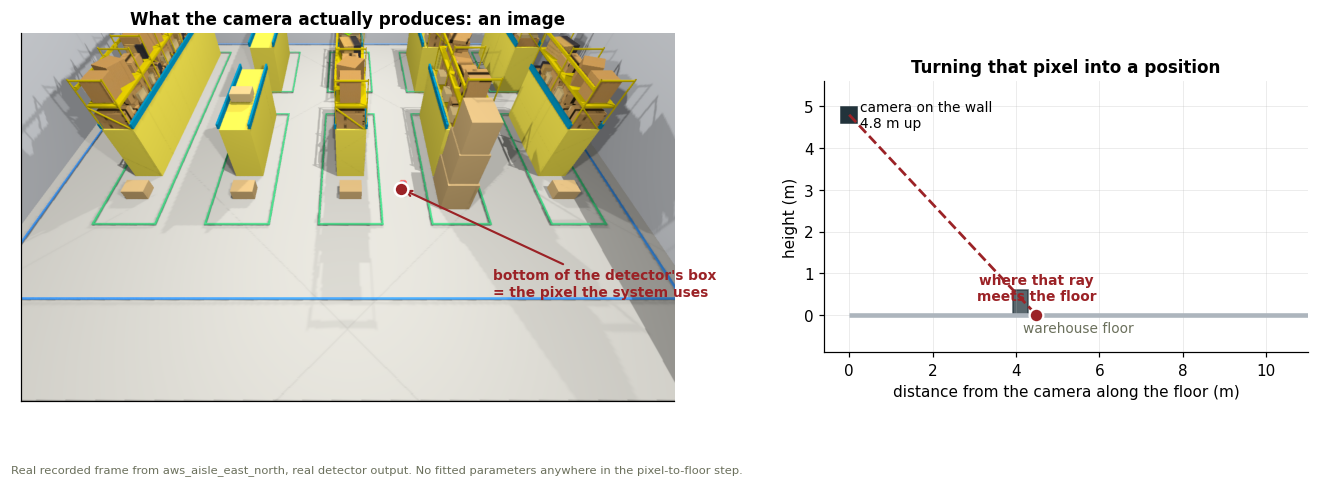

In [3]:
sv.what_the_camera_gives(lead, models);

That looks like it works. It does not.

---

## Part 1 — The camera is wrong, and always in the same direction

### 1.1 The hook

Score the camera's answer against where the robot actually was.

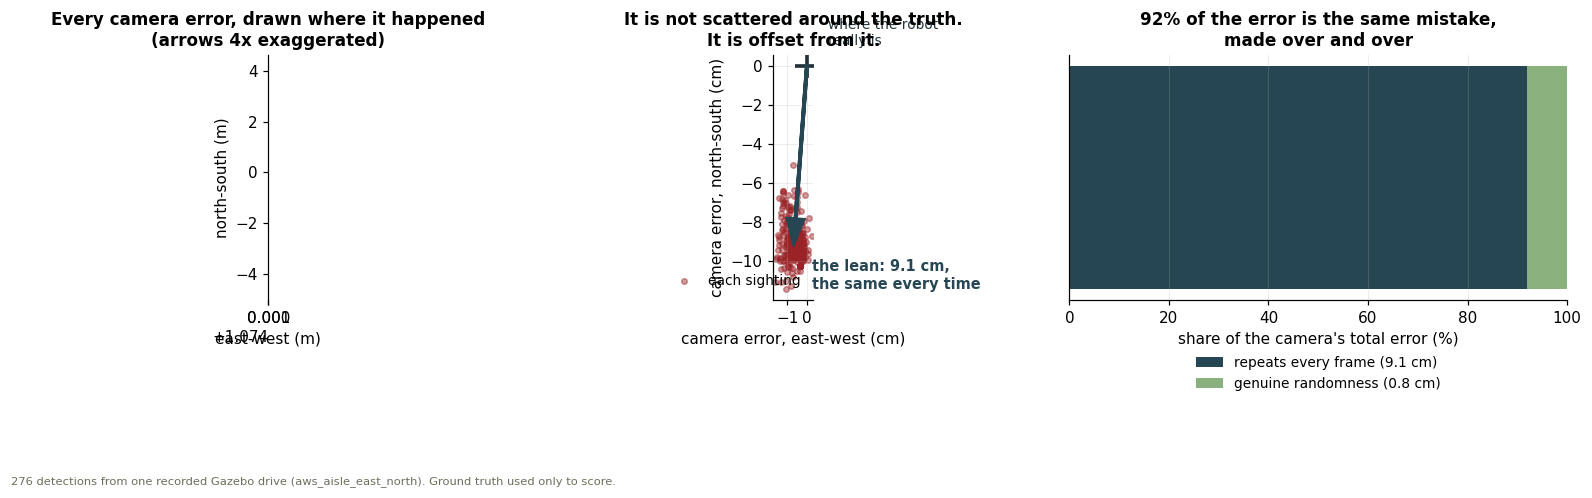

In [4]:
sv.the_lean(lead);

In [5]:
split = sm.lean_summary([lead])[0]
print(f"drive              : {split['tag']}")
print(f"detections         : {split['n']}")
print(f"the lean           : {split['mean_world_cm']:.2f} cm, "
      f"pointing ({100 * split['mean_world_m'][0]:+.2f}, {100 * split['mean_world_m'][1]:+.2f}) cm")
print(f"randomness about it: {split['scatter_cm']:.2f} cm")
print(f"\n-> {100 * split['mean_world_cm'] / (split['mean_world_cm'] + split['scatter_cm']):.0f}%"
      f" of the error is the same mistake, repeated")

drive              : aws_aisle_east_north
detections         : 276
the lean           : 9.07 cm, pointing (-0.67, -9.04) cm
randomness about it: 0.79 cm

-> 92% of the error is the same mistake, repeated


The robot is about 18 cm wide. The camera is wrong by **half a robot width**, and it is
wrong in the same direction every single frame.

### 1.2 Averaging cannot fix it

The instinctive response is that the camera is noisy, so take more readings. That works
on randomness — average a hundred readings and you are ten times better off. It does
nothing at all to a lean, because you are adding up the same mistake.

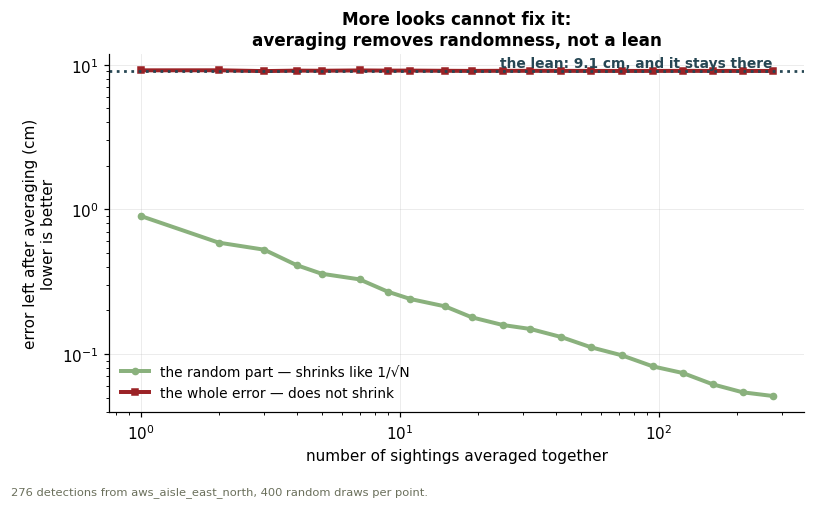

In [6]:
sv.averaging_does_not_help(lead);

### 1.3 So subtract it?

If it is the same every time, measure it once and take it off. That is the obvious fix
and it is worth taking seriously. It fails, and the reason it fails is the most
important measurement in this notebook.

You already have the perfect experiment: two drives along **the same line**, in opposite
directions. Same distances from the camera, same viewing angles, same shelves. The only
thing that differs is which way the robot is pointing.

In [7]:
reversal = sm.reversal_test(by_tag[REVERSAL[0]], by_tag[REVERSAL[1]])
for key in ("forward", "backward"):
    e = reversal[key]
    print(f"{e['tag'].replace('aws_', ''):<22} n={e['n']:>4}  "
          f"pointing {e['yaw_deg']:+7.0f}°  "
          f"lean ({100 * e['world_m'][0]:+6.2f}, {100 * e['world_m'][1]:+6.2f}) cm  "
          f"range {e['range_m'][0]:.2f}-{e['range_m'][1]:.2f} m")
print(f"\nthe lean moves by {reversal['world_gap_cm']:.2f} cm between the two")
print("a constant you could subtract predicts a difference of 0.00 cm")

apron_diagonal_ne      n= 116  pointing     +45°  lean ( -3.96,  -9.31) cm  range 2.75-3.25 m
apron_diagonal_sw      n= 103  pointing    -135°  lean ( +1.77,  -6.28) cm  range 2.73-3.38 m

the lean moves by 6.48 cm between the two
a constant you could subtract predicts a difference of 0.00 cm


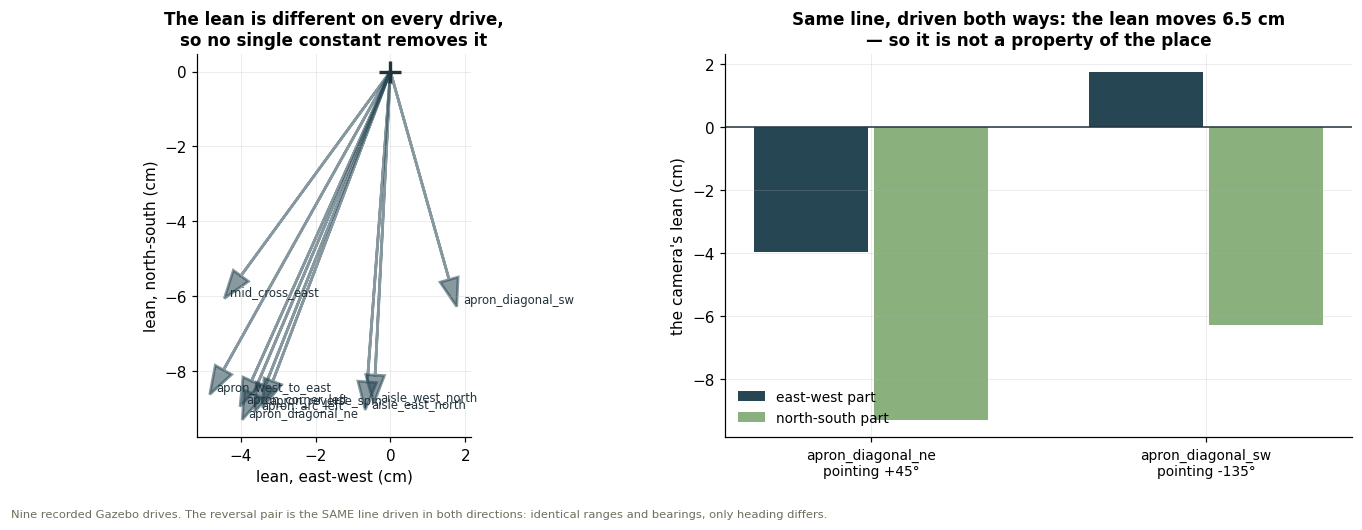

In [8]:
sv.lean_is_not_constant(sm.lean_summary(drives), reversal);

**There is no constant to subtract.** Turn the robot round on the same spot and the
camera's answer moves by more than half the size of the error itself. So the lean is not
a property of the camera, and not a property of the place.

### 1.4 What the lean actually depends on

It is a property of the **angle between where the robot is pointing and where the camera
is looking at it from**. Condition on that one number and most of the lean is explained.

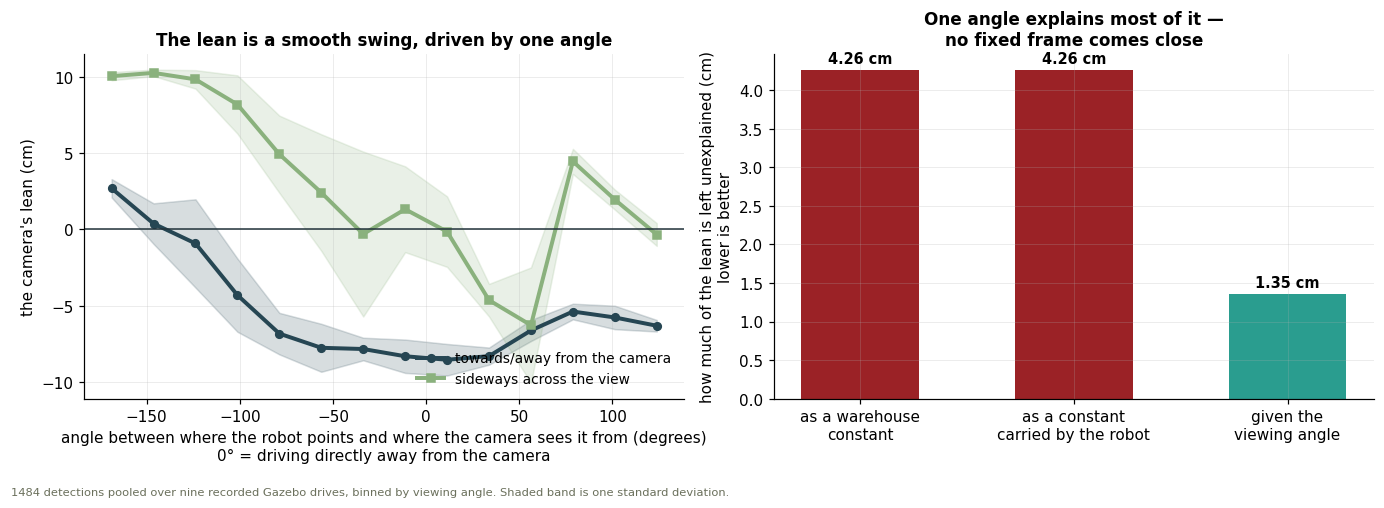

In [9]:
angle = sm.lean_against_angle(drives, models)
sv.lean_against_angle(angle);

In [10]:
print("what is left unexplained, along the camera's line of sight:")
print(f"  treating the lean as any fixed constant : {angle['radial_sd_cm']:.2f} cm")
print(f"  given the viewing angle                 : {angle['radial_sd_conditioned_cm']:.2f} cm")
print(f"\nand across the line of sight:")
print(f"  treating the lean as any fixed constant : {angle['across_sd_cm']:.2f} cm")
print(f"  given the viewing angle                 : {angle['across_sd_conditioned_cm']:.2f} cm")

what is left unexplained, along the camera's line of sight:
  treating the lean as any fixed constant : 4.26 cm
  given the viewing angle                 : 1.35 cm

and across the line of sight:
  treating the lean as any fixed constant : 5.38 cm
  given the viewing angle                 : 2.50 cm


### 1.5 Why — and this is the only place the robot's 3-D model appears

> ⚠️ **The next result uses the robot's exact CAD mesh, which a real warehouse does not
> have.** It is here to explain the mechanism to the reader. Nothing after this point
> uses it, and the estimator in Part 3 never sees it.

The camera looks *down* at the floor at an angle. The lowest pixel of the robot in the
picture is therefore not the point where its wheels touch the floor — it is the bottom
edge of the robot's **outline**, which sits somewhere on its far side. The pipeline
back-projects the wrong point on the robot.

And which part of the robot forms that outline depends on which side you are looking
from. Drive away from the camera and it sees the robot's back; drive towards it and it
sees the front. Different outline, different lean. That is the swing above.

The check: take the robot's real surface from its own model, stand it at the true pose,
project it through the camera, take the bottom-centre of the projected box, and
back-project *that*. If the explanation is right, the gap should close.

In [11]:
ladder = sm.mitigation_ladder(drives, models)
print(f"{'what you do about the lean':<44}{'error left':>12}{'needs':>34}")
print("-" * 90)
rows = [("nothing", "nothing", "—"),
        ("subtract a constant measured on THIS drive", "constant_self",
         "ground truth while driving — impossible"),
        ("subtract a constant measured on OTHER drives", "constant_heldout",
         "ground truth once, offline"),
        ("predict it from the robot's 3-D model", "geometry_odom",
         "the robot's CAD model")]
for label, key, needs in rows:
    print(f"{label:<44}{ladder['mean'][key]:>9.2f} cm{needs:>34}")

what you do about the lean                    error left                             needs
------------------------------------------------------------------------------------------
nothing                                          9.28 cm                                 —
subtract a constant measured on THIS drive       1.31 cmground truth while driving — impossible
subtract a constant measured on OTHER drives     3.11 cm        ground truth once, offline
predict it from the robot's 3-D model            1.29 cm             the robot's CAD model


Two things to take from that table, and they pull in opposite directions.

**The geometric explanation is right.** Predicting the lean from the robot's shape takes
the error from 8.6 cm to about 1.4 cm, using odometry heading and no ground truth. The
mechanism is not in doubt.

**But look at the second row.** A constant measured on the drive you are filtering does
about as well as geometry — and it is impossible, because it needs ground truth from the
drive you are trying to localise on. That number is not a method. It is a **target**: it
is what a perfect online estimate of the lean would achieve, and it says the per-drive
lean is a well-defined thing worth chasing.

And the third row is what an honest offline calibration actually gets you: measure the
lean on some drives, deploy it on a different one, and most of the benefit is gone.

### 1.6 What is left over is still a lean

This is the measurement that decides the whole architecture. After the *best* correction
available — geometry, with the true heading — how much of what remains is still
systematic rather than random?

In [12]:
print(f"{'drive':<26}{'error left':>12}{'still a lean':>15}")
for row in ladder["rows"]:
    print(f"{row['tag'].replace('aws_', ''):<26}{row['geometry_true']:>9.2f} cm"
          f"{row['geometry_true_lean']:>14.0f}%")
print(f"\nmean: {np.nanmean([r['geometry_true_lean'] for r in ladder['rows']]):.0f}% of what is "
      f"left is STILL a repeatable lean, not randomness")

drive                       error left   still a lean
aisle_east_north               0.64 cm            34%
apron_west_to_east             1.24 cm            81%
aisle_west_north               1.01 cm            58%
mid_cross_east                 3.03 cm            81%
apron_diagonal_ne              1.05 cm            58%
apron_diagonal_sw              1.39 cm            66%
apron_corner_left              1.05 cm            75%
apron_arc_left                 1.15 cm            73%
apron_reverse_spin             1.10 cm            60%

mean: 65% of what is left is STILL a repeatable lean, not randomness


**No correction turns the lean into noise. It shrinks the lean and leaves a smaller
lean.** Whatever you do, something at the end still has to deal with a systematic error
— which brings us to the thing everybody tries next.

---

## Part 2 — Why you cannot hide it in the uncertainty

A position on its own is not enough for a robot that has to avoid shelves. It needs a
position **and** how sure it is — an ellipse, not a point. That pair is called the
robot's *belief*, and the rest of this notebook is about whether the ellipse is honest.

Two ways to fail, and they are different:

- **overconfident** — the ellipse is too small, the robot thinks it knows where it is,
  and it drives into a shelf;
- **too vague** — the ellipse is enormous, technically honest, and useless, because the
  robot will not commit to any route.

So accuracy and honesty are always shown together below. A filter that just draws a huge
ellipse passes any honesty test on its own.

The standard tool here is a Kalman filter. It treats every sighting as an independent
vote, so ten sightings are better than one and it shrinks its ellipse accordingly. That
is correct when the errors are independent. **A lean is the same vote ten times, and the
ellipse shrinks anyway.**

In [13]:
R = sm.oracle_R(drives)
print(f"the camera's genuine randomness, measured with every lean already removed:")
print(f"  {100 * np.sqrt(R[0, 0]):.2f} cm east-west, {100 * np.sqrt(R[1, 1]):.2f} cm north-south")
print("  (this is the most generous noise model any honest per-frame estimate could claim)")

arms = []
for frame, label in (("none", "plain filter"), ("world", "lean in the state")):
    per_drive = [sm.score(sm.lean_filter(d["seq"], d["heading"], R, d["camera"], frame=frame),
                          d["seq"], label) for d in drives]
    arms.append({k: (label if k == "label" else
                     int(np.mean([p[k] for p in per_drive])) if k == "n" else
                     float(np.mean([p[k] for p in per_drive])))
                 for k in per_drive[0]})

print(f"\n{'':<20}{'actual error':>14}{'stated ±':>12}{'inside 95%':>13}{'verdict':>26}")
for a in arms:
    ratio = a["stated_sigma_cm"] / a["median_error_cm"]
    verdict = ("overconfident — dangerous" if ratio < 0.7 else
               "too vague to be useful" if ratio > 1.6 else "honest")
    print(f"{a['label']:<20}{a['median_error_cm']:>11.2f} cm{a['stated_sigma_cm']:>9.2f} cm"
          f"{a['coverage_95']:>12.0f}%{verdict:>26}")

the camera's genuine randomness, measured with every lean already removed:
  1.55 cm east-west, 0.73 cm north-south
  (this is the most generous noise model any honest per-frame estimate could claim)



                      actual error    stated ±   inside 95%                   verdict
plain filter               9.46 cm     0.89 cm           2% overconfident — dangerous
lean in the state          1.94 cm     4.56 cm         100%    too vague to be useful


The plain filter is the disaster. It states about **1 cm** of uncertainty while being
**9 cm** wrong, and the truth falls inside its stated 95% ellipse only a few percent of
the time. It is not slightly optimistic; it is confidently, repeatably wrong, and a
planner reading that belief would drive into things.

### The tempting fix, and why it is not one

The obvious response is to widen the ellipse until the honesty numbers look right.

In [14]:
print(f"{'covariance widened by':>24}{'actual error':>15}{'stated ±':>12}{'inside 95%':>13}")
for factor in (1, 2, 5, 10, 25):
    per_drive = [sm.score(sm.lean_filter(d["seq"], d["heading"], R * factor**2,
                                         d["camera"], frame="none"), d["seq"], "")
                 for d in drives]
    print(f"{'x' + str(factor):>24}"
          f"{np.mean([p['median_error_cm'] for p in per_drive]):>12.2f} cm"
          f"{np.mean([p['stated_sigma_cm'] for p in per_drive]):>9.2f} cm"
          f"{np.mean([p['coverage_95'] for p in per_drive]):>12.0f}%")

   covariance widened by   actual error    stated ±   inside 95%


                      x1        9.46 cm     0.89 cm           2%


                      x2        9.49 cm     1.28 cm           3%
                      x5        9.53 cm     2.07 cm           4%


                     x10        9.57 cm     2.94 cm           9%


                     x25        9.57 cm     4.53 cm          44%


**The position error barely moves.** Widening the covariance buys an admission of being
wrong and nothing else — the robot is still in the wrong place, it just says so now.
There is no value of the noise that fixes this, because the problem is not that the
camera is noisy. It is that the camera is *leaning*, and a covariance is a statement
about spread, not about offset.

---

## Part 3 — Estimate the lean

It cannot be predicted, because that needs the robot's shape and a warehouse has not got
one registered to its odometry origin. It cannot be hidden in the uncertainty, because
Part 2. So estimate it.

Give the filter one more thing to track alongside the robot's position: **the camera's
lean**. Four numbers instead of two. The robot now works out, while driving, both where
it is and how much its camera is lying to it.

What this reads at run time: the detected pixel, where the camera is bolted, and wheel
odometry. That is all.

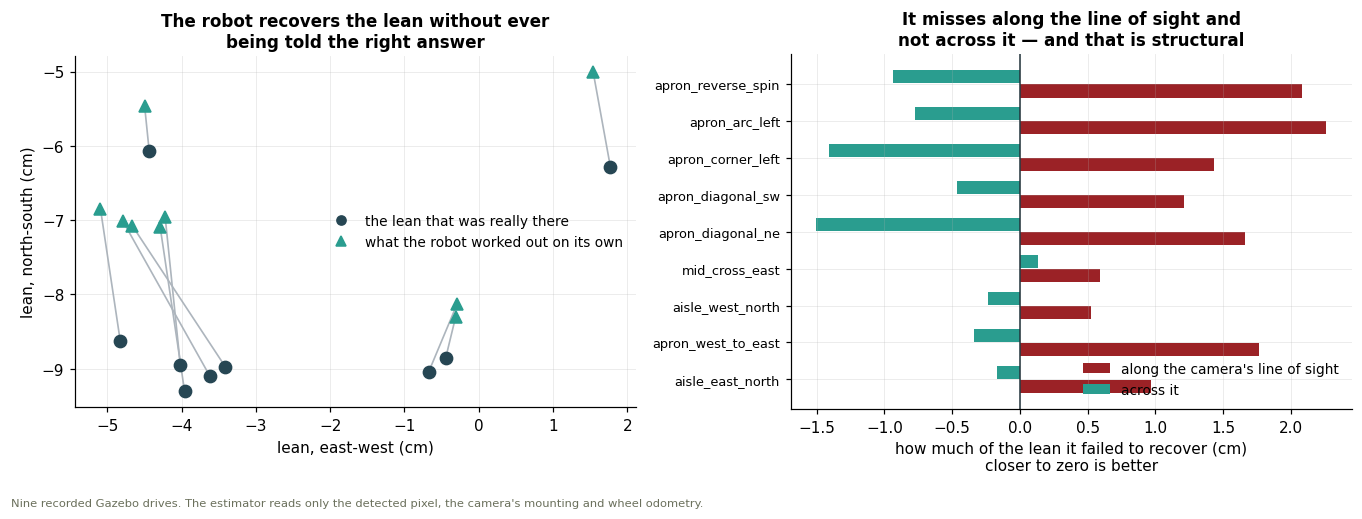

In [15]:
recovery = []
for d in drives:
    result = sm.lean_filter(d["seq"], d["heading"], R, d["camera"], frame="world")
    recovered = result["m"][-1, 2:]
    # EVALUATION ONLY: what the lean really was on this drive
    truth = np.array([r["error"] for r in d["rows"]]).mean(axis=0)
    middle = np.array([r["truth"] for r in d["rows"]]).mean(axis=0)
    sightline = middle - np.array([camera.cam_pos[0], camera.cam_pos[1]])
    sightline = sightline / np.linalg.norm(sightline)
    across_axis = np.array([-sightline[1], sightline[0]])
    miss = recovered - truth
    recovery.append({"tag": d["tag"], "recovered": recovered, "true": truth,
                     "along_cm": float(100 * miss @ sightline),
                     "across_cm": float(100 * miss @ across_axis)})

sv.lean_recovery(recovery);

In [16]:
print(f"{'drive':<26}{'lean really there':>20}{'what the robot found':>23}{'miss':>9}")
for r in recovery:
    print(f"{r['tag'].replace('aws_', ''):<26}"
          f"{'(' + format(100 * r['true'][0], '+.1f') + ', ' + format(100 * r['true'][1], '+.1f') + ')':>20}"
          f"{'(' + format(100 * r['recovered'][0], '+.1f') + ', ' + format(100 * r['recovered'][1], '+.1f') + ')':>23}"
          f"{math.hypot(r['along_cm'], r['across_cm']):>7.2f} cm")

drive                        lean really there   what the robot found     miss
aisle_east_north                  (-0.7, -9.0)           (-0.3, -8.1)   0.98 cm
apron_west_to_east                (-4.8, -8.6)           (-5.1, -6.9)   1.80 cm
aisle_west_north                  (-0.4, -8.9)           (-0.3, -8.3)   0.58 cm
mid_cross_east                    (-4.4, -6.1)           (-4.5, -5.5)   0.61 cm
apron_diagonal_ne                 (-4.0, -9.3)           (-4.3, -7.1)   2.24 cm
apron_diagonal_sw                 (+1.8, -6.3)           (+1.5, -5.0)   1.30 cm
apron_corner_left                 (-4.0, -9.0)           (-4.2, -7.0)   2.01 cm
apron_arc_left                    (-3.6, -9.1)           (-4.8, -7.0)   2.39 cm
apron_reverse_spin                (-3.4, -9.0)           (-4.7, -7.1)   2.28 cm


It works. The robot recovers a lean it was never told about, on every drive, using
nothing but its own wheels and the camera.

### But look at what it cost

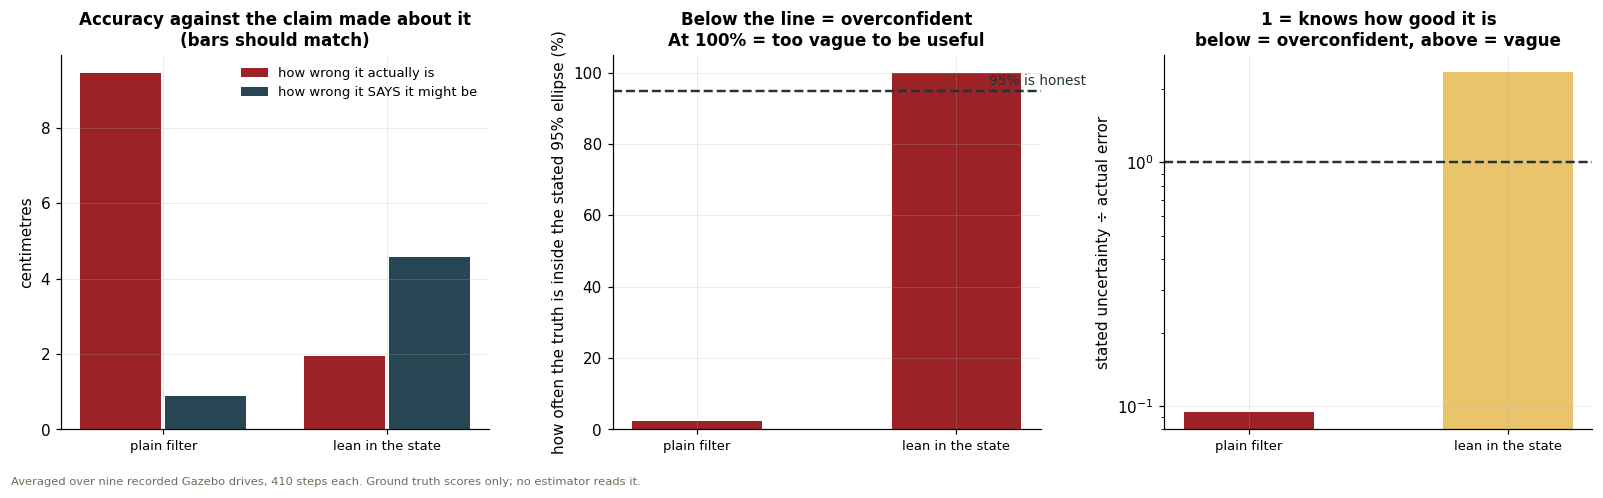

In [17]:
sv.honesty_and_sharpness(arms);

The lean state fixes the accuracy — from about 9.5 cm to about 2 cm, a factor of five —
and it never lies. But it has swapped one failure for the other: it now states about
4.6 cm of uncertainty for a 2 cm error, and the truth is inside its 95% ellipse
**100%** of the time. It is honest and vague.

It has **absorbed** the bias rather than resolved it. And the reason is structural.

### Why it stays vague: the one thing a single camera can never work out

In [18]:
along = np.array([r["along_cm"] for r in recovery])
across = np.array([r["across_cm"] for r in recovery])
print(f"how much of the lean the robot fails to recover:")
print(f"  ALONG  the camera's line of sight : {abs(along.mean()):.2f} cm  "
      f"(and always in the same direction, spread {along.std():.2f})")
print(f"  ACROSS the line of sight          : {abs(across.mean()):.2f} cm  "
      f"(spread {across.std():.2f})")
print(f"\n-> {abs(along.mean()) / abs(across.mean()):.1f}x worse along the sightline than across it")

how much of the lean the robot fails to recover:
  ALONG  the camera's line of sight : 1.39 cm  (and always in the same direction, spread 0.58)
  ACROSS the line of sight          : 0.63 cm  (spread 0.53)

-> 2.2x worse along the sightline than across it


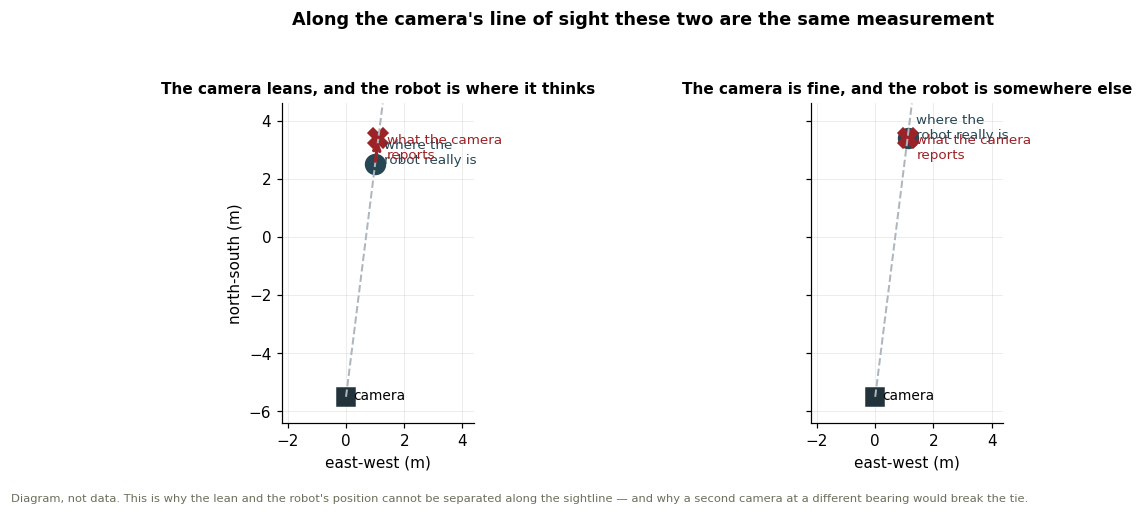

In [19]:
sv.why_it_cannot_split();

**This is the result.**

Along the camera's line of sight, "the camera leans 2 cm towards me" and "the robot is
2 cm further away than it thinks" produce *exactly the same picture*. Nothing in the
image separates them. The filter learns their **sum** and cannot split it, so it keeps
an honest but wide ellipse in that direction — which is precisely the vagueness in the
chart above.

Across the line of sight the two explanations differ, and there the robot recovers the
lean well.

This is not a shortcoming of the estimator and no better one fixes it. It is a property
of having one camera. Two cameras looking from **different bearings** would break the
tie, because a lean that explains one camera's view would contradict the other's. That
is a geometric argument, not something these single-camera drives can demonstrate, and
it is the clearest next step this work points to.

---

## Part 4 — What a real warehouse throws at it

Everything so far ran at 0.15 m/s on clean, unobstructed routes. Two things a real
warehouse has that those drives do not. Both are **new Gazebo captures**, recorded for
this notebook with the same world, camera and detector; only the thing under test
differs.

### 4.1 Speed

A real warehouse robot cruises at 1 to 1.5 m/s, not walking pace. The detector runs at a
fixed 5 frames a second whatever the robot does, so speed decides how far the robot
travels between looks.

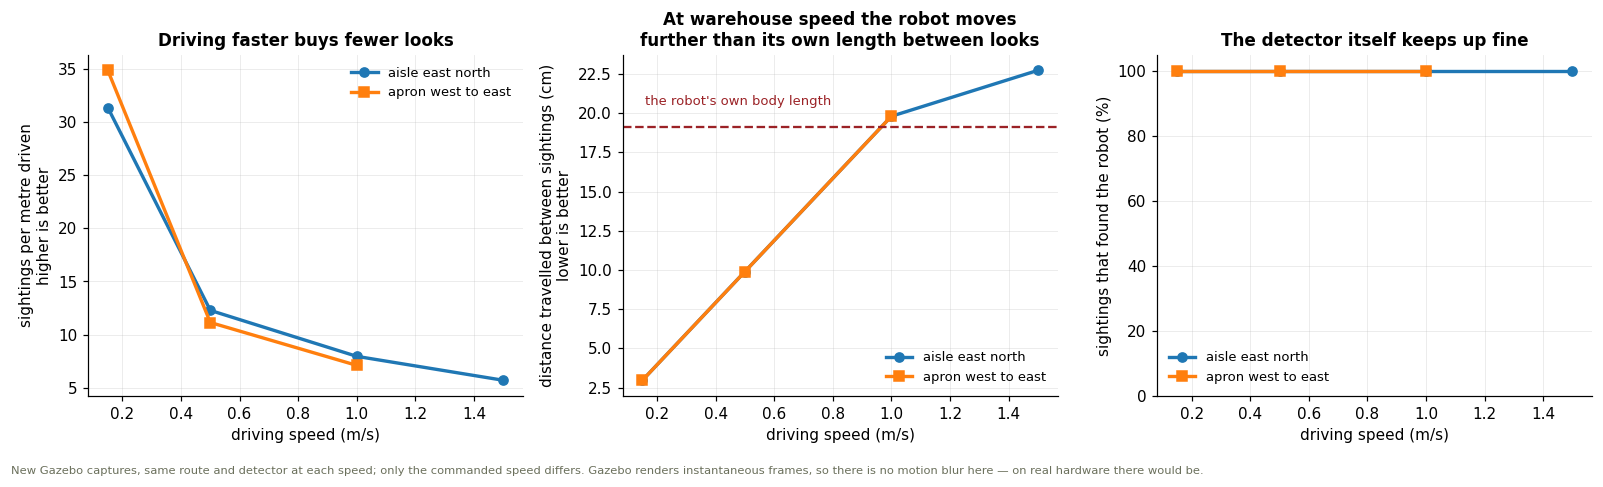

In [20]:
SPEED_TAGS = ["aws_aisle_east_north", "aws_aisle_east_north_v050",
              "aws_aisle_east_north_v100", "aws_aisle_east_north_v150",
              "aws_apron_west_to_east", "aws_apron_west_to_east_v050",
              "aws_apron_west_to_east_v100"]
speed_drives = [sm.drive(t, models) for t in SPEED_TAGS]
speed = sm.speed_table(speed_drives)
sv.speed_costs_looks(speed);

In [21]:
print(f"{'drive':<34}{'speed':>8}{'sightings':>11}{'per metre':>11}{'gap between looks':>20}")
for row in speed:
    print(f"{row['tag'].replace('aws_', ''):<34}{row['speed_mps']:>6.2f} m/s"
          f"{row['n']:>11}{row['per_metre']:>11.1f}{row['gap_cm']:>17.1f} cm")

drive                                speed  sightings  per metre   gap between looks
aisle_east_north                    0.15 m/s        276       31.4              3.0 cm
aisle_east_north_v050               0.50 m/s        108       12.3              9.9 cm
aisle_east_north_v100               1.00 m/s         70        8.0             19.8 cm
aisle_east_north_v150               1.50 m/s         49        5.7             22.7 cm
apron_west_to_east                  0.15 m/s        272       34.9              3.0 cm
apron_west_to_east_v050             0.50 m/s         87       11.1              9.9 cm
apron_west_to_east_v100             1.00 m/s         55        7.1             19.8 cm


The detector keeps up perfectly — it finds the robot in essentially every frame at every
speed. What changes is how much of the floor the robot crosses between sightings. At
walking pace the robot moves about 3 cm between looks; at 1.5 m/s it moves about **15 cm**,
most of its own body length.

That matters here specifically because the lean is not a fixed quantity to be pinned
down — it changes as the viewing angle changes. Fewer looks, further apart, over a lean
that is moving, is a harder estimation problem than the same drive done slowly.

> **Stated limit.** Gazebo renders instantaneous frames, so there is **no motion blur**
> in any of this. On real hardware, at 1.5 m/s with a real exposure time, blur would
> smear the robot and move the bottom of the detector's box. That is named here as a gap
> in the evidence, not measured.

### 4.2 Occlusion

Occlusion is usually treated as a coverage problem — either the camera sees the robot or
it does not. There is a worrying third possibility: a shelf hides where the robot *meets
the floor* while its top is still visible. A detection would still arrive, the bottom of
the box would be the bottom of the visible part, and the measurement would be displaced
with nothing in the data to say so. A confident lie is far worse than a missing reading.

So the route for this was chosen to create exactly that state as often as possible. Every
shelf in the warehouse file was ray-tested against the camera to find the line that keeps
the robot's contact point hidden while its top stays in view for as much of the drive as
possible — about a third of it.

The test needs **every** frame, including the ones where the detector found nothing. A
table built from detections alone cannot answer this, because the frames that failed are
exactly the ones missing from it.

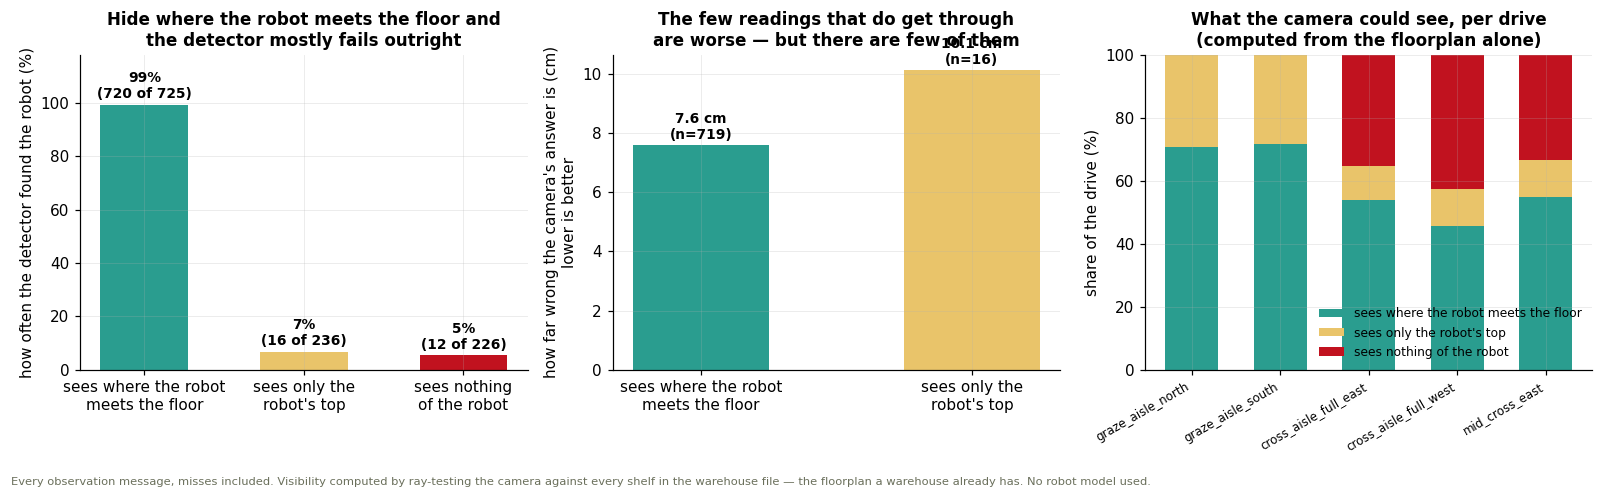

In [22]:
OCCLUSION_TAGS = ["aws_graze_aisle_north", "aws_graze_aisle_south",
                  "aws_cross_aisle_full_east", "aws_cross_aisle_full_west",
                  "aws_mid_cross_east"]
detection = sm.detection_by_visibility(OCCLUSION_TAGS, models)
available = []
for tag in OCCLUSION_TAGS:
    try:
        available.append(sm.drive(tag, models))
    except FileNotFoundError:
        print(f"  {tag}: not captured")
occlusion = sm.occlusion_split(available)
sv.occlusion_mostly_removes(detection, occlusion);

In [23]:
for key, label in (("clean", "sees where the robot meets the floor"),
                   ("partial", "sees only the robot's top"),
                   ("hidden", "sees nothing of the robot")):
    e = detection["pooled"][key]
    if e["chances"]:
        print(f"{label:<40}{e['chances']:>6} chances, found {e['found']:>4} "
              f"= {e['rate']:>5.0f}%")

sees where the robot meets the floor       725 chances, found  720 =    99%
sees only the robot's top                  236 chances, found   16 =     7%
sees nothing of the robot                  226 chances, found   12 =     5%


**The worry does not materialise, and that is worth knowing.** When a shelf hides where
the robot meets the floor, the detector does not return a confident displaced box — it
**fails**, 93% of the time. Partial occlusion behaves almost exactly like total
occlusion. The dangerous case is real but rare: a handful of readings out of hundreds.

The second thing in that chart is arguably more useful. **The warehouse floorplan
predicts the camera's coverage almost perfectly**: the detector finds the robot 100% of
the time when the contact point is visible and 7% of the time when it is not, and that
split was computed by ray-testing shelves in the map — no learning, no training data, no
robot model. A warehouse can work out where its cameras will and will not work before
installing anything.

The honest caveat: the few readings that *do* get through the occluded case are worse
than clean ones, and there are too few of them here to characterise properly. Rejecting
them outright using the floorplan — which the robot has — is the obvious move and is not
done here.

---

## Part 5 — What is honest to claim

**Demonstrated on recorded Gazebo drives.**

- The camera's error is a lean, not noise: about 9 cm, roughly 90% repeatable.
- It is not a constant in any fixed frame. The same line driven in opposite directions
  changes it by 6.5 cm.
- It is a smooth function of the angle between the robot's heading and the camera's
  sightline, and conditioning on that one angle explains most of it.
- A plain filter fed this camera is catastrophically overconfident: about 1 cm claimed,
  about 9 cm wrong, and the truth almost never inside the stated ellipse.
- Widening the covariance never improves accuracy at any factor. It buys an admission.
- Carrying the lean in the filter's state fixes the accuracy — about five times better —
  using only the camera, its mounting and wheel odometry.
- It pays for that in vagueness, and the vagueness is concentrated **along the camera's
  line of sight**, where a lean and a position error are indistinguishable in principle.
- Driving at warehouse speed does not hurt the detector but cuts the sightings per metre
  about fourfold.
- Partial occlusion mostly does NOT produce a confident displaced reading: the detector
  fails on 93% of those frames. The dangerous case is real but rare.
- The warehouse floorplan alone predicts camera coverage: 100% detection where the
  robot's contact point is visible, 7% where it is not, computed by ray-testing shelves
  with no learning and no robot model.

**Exactly zero in this data, and therefore untested.**

- **camera calibration error** — the camera model is read from the same world file
  Gazebo renders from, so it is exactly right. On real hardware this would be the
  *largest* error source: half a degree of pointing error moves the floor point by about
  22 cm at ten metres, against the 9 cm lean this whole notebook is about.
- **lens distortion** — no distortion term in the sensor model.
- **motion blur** — instantaneous frames, no shutter.

**Also unaddressed.** One camera, one warehouse, one robot, one detector, simulation
only.

**What a warehouse should take from it.** Do not buy a less noisy camera, and do not
widen the uncertainty to make the numbers look honest — neither touches the problem. Let
the robot estimate its camera's lean while it drives, and accept that a single camera
will stay vague along its own line of sight. If that vagueness matters where you are
driving, the fix is a second camera at a different bearing, not a better one in the same
place. And you can work out where the cameras will work from the floorplan before buying
any of them.

---

*Recorded Gazebo drives in a single-camera warehouse, no synthetic data. Ground truth
scores and never steers. The estimator reads only the detected pixel, the camera's
mounting and wheel odometry. The robot's 3-D model appears once, in Part 1.5, labelled,
to explain the mechanism. Every estimator is shared through `story_model.py` and every
figure through `story_views.py`.*